[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aims-ai-research-foundations/airf-capstone-project-recipes/blob/main/projects/african-language-synthetic-data/notebook.ipynb)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-black?logo=github)](https://github.com/aims-ai-research-foundations/airf-capstone-project-recipes/blob/main/projects/african-language-synthetic-data/notebook.ipynb)
[![Dataset](https://img.shields.io/badge/Dataset-Hugging%20Face-yellow?logo=huggingface)](https://huggingface.co/datasets/Similoluwa/capstone-datasets/viewer/african_language_synthetic_data)

# Build a Synthetic Dataset for an African Language

**Project Category:** Classification

## Problem

Most African languages lack the labelled data needed to train and evaluate language models.

## What You'll Build

A synthetic Swahili intent dataset generated with Gemma 4B from a small real seed set, filtered, documented and used to fine-tune Gemma 1B, then tested on real data.

## Research Question

> Under what conditions does Gemma-generated synthetic data help a language model learn a Swahili intent task when real labelled data is scarce?

## What You'll Learn

- Design controllable generation prompts from a small seed set
- Filter synthetic text with length checks, language identification and embedding-based deduplication
- Fine-tune a language model on real, synthetic and combined data and compare them on a real test set
- Assess dataset quality with an LLM judge and a native speaker
- Write a dataset card and publish a dataset on Hugging Face

## Setup

- Create a free Hugging Face account at [huggingface.co/join](https://huggingface.co/join).
- Accept the Gemma licence on the [Gemma 3 1B](https://huggingface.co/google/gemma-3-1b-it) and [Gemma 3 4B](https://huggingface.co/google/gemma-3-4b-it) model pages.
- Create a Hugging Face access token ([settings/tokens](https://huggingface.co/settings/tokens), **Read** access) and add it to Google Colab Secrets as `HF_TOKEN`, with notebook access turned on.
- Open the notebook in Google Colab.
- Enable a GPU under **Runtime → Change runtime type → T4 GPU**.
- To publish your dataset, give your `HF_TOKEN` **Write** access.
- Create a free Gemini API key in [Google AI Studio](https://aistudio.google.com/api-keys) and add it to Colab Secrets as `GEMINI_API_KEY` (steps below). Gemini is used only as an independent judge on a few examples.

---

### Creating a Gemini API key

Follow the four steps, then add the key to Colab: key icon (**Secrets**) in the left sidebar → **Add new secret** → name `GEMINI_API_KEY`, paste the key, and turn on **Notebook access**. Treat the key like a password: never paste it into a cell or share a screenshot of it.

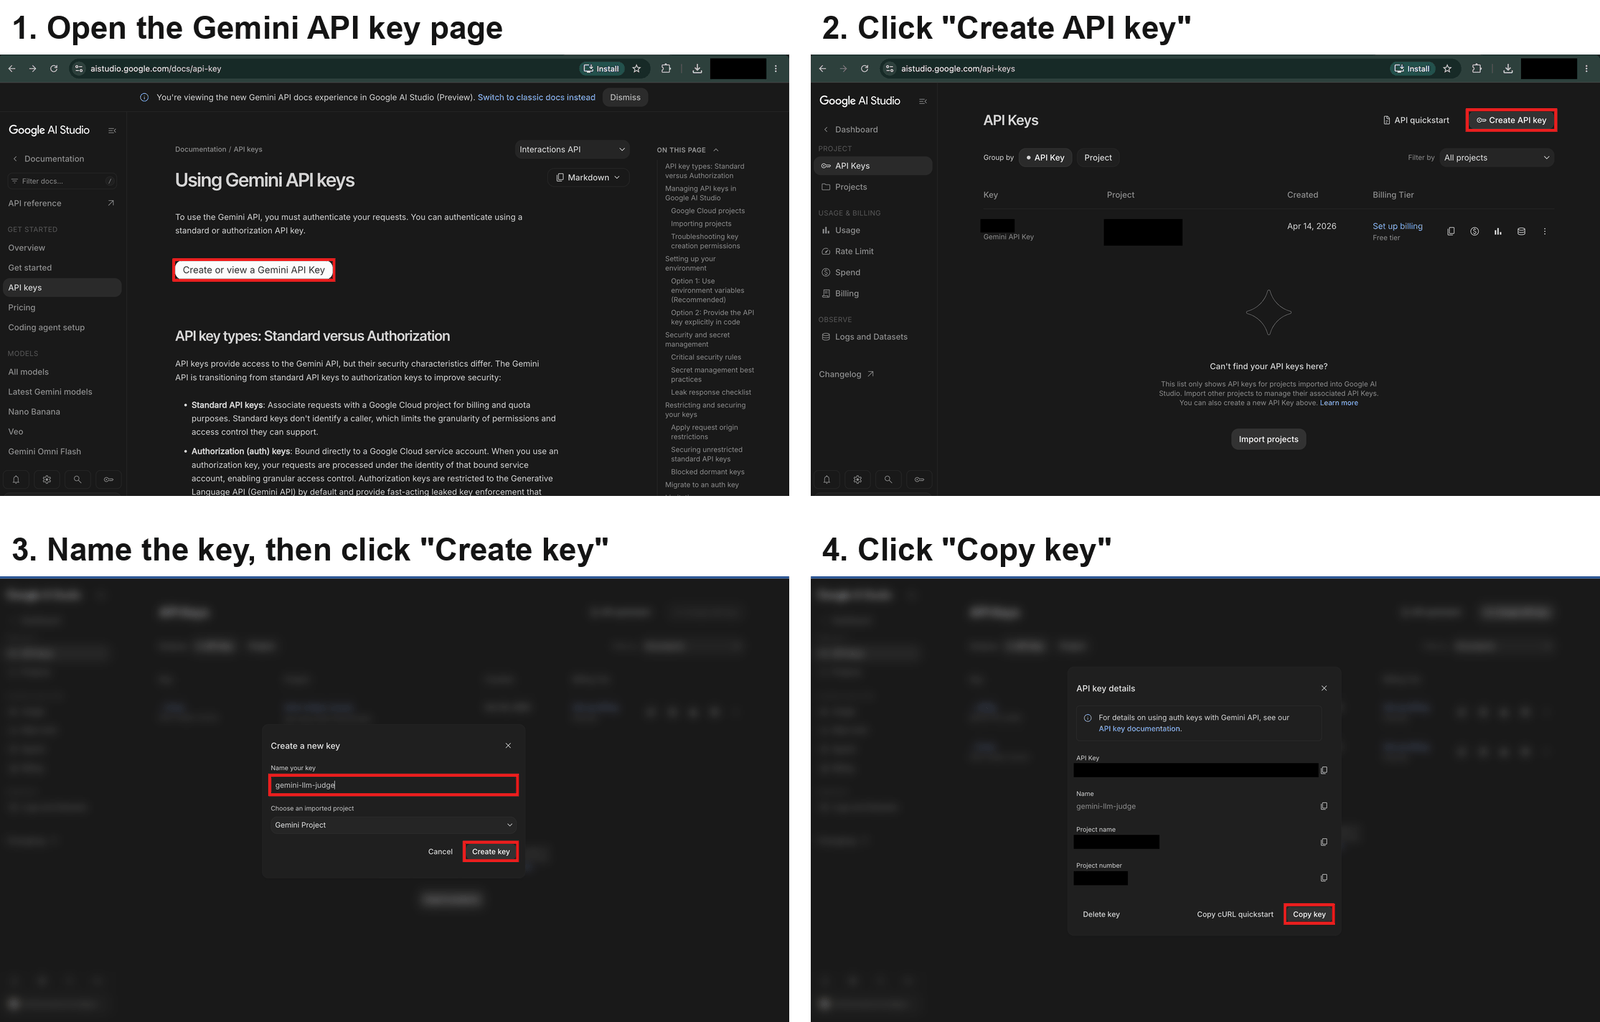

## Install Required Libraries

In [ ]:
!pip install -q --progress-bar off transformers==5.17.0 datasets==5.0.1 accelerate==1.15.0 peft==0.21.0 trl==1.14.0 bitsandbytes scikit-learn sentence-transformers==6.1.0 lingua-language-detector==2.2.0 google-genai==2.25.0

## Import Libraries

In [ ]:
import gc
import json
import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import transformers
from datasets import Dataset, DatasetDict, load_dataset
from google import genai
from google.genai import errors, types
from huggingface_hub import DatasetCard, login
from lingua import Language, LanguageDetectorBuilder
from peft import LoraConfig
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, Pipeline, pipeline
from trl import SFTConfig, SFTTrainer

In [ ]:
# Log in to Hugging Face so the gated Gemma models can be downloaded.
try:
    from google.colab import userdata

    login(token=userdata.get("HF_TOKEN"))
except ImportError:
    pass  # Outside Colab, run `hf auth login` once in a terminal instead.

In [ ]:
# Connect to Gemini, which judges a few answers as an independent, stronger model.
# Gemini is sometimes busy (error 503), so each request is retried a few times with a growing pause.
retry = types.HttpOptions(
    retry_options=types.HttpRetryOptions(attempts=4, initial_delay=5, max_delay=60)
)
try:
    from google.colab import userdata

    gemini = genai.Client(api_key=userdata.get("GEMINI_API_KEY"), http_options=retry)
except ImportError:
    gemini = genai.Client(
        http_options=retry
    )  # Outside Colab, reads GEMINI_API_KEY from the environment.

## Settings

In [ ]:
GENERATOR_ID = "google/gemma-3-4b-it"  # writes the synthetic data
CLASSIFIER_ID = "google/gemma-3-1b-it"  # fine-tuned on real / synthetic / combined data
EMBEDDING_MODEL_ID = "google/embeddinggemma-300m"  # finds near-duplicates
JUDGE_MODEL_ID = "gemini-3.5-flash-lite"  # rates a few synthetic utterances
CALLS_PER_INTENT = 3  # generation prompts per intent
UTTERANCES_PER_CALL = 5  # new utterances requested per prompt
MIN_SWAHILI_CONFIDENCE = 0.5  # language-ID threshold
MAX_SIMILARITY = 0.95  # near-duplicate threshold (embedding cosine)
BATCH_SIZE = 8
SEED = 42
HF_DATASET_REPO = None  # e.g. "your-username/injongo-swa-synthetic" to publish

## Helpers

Reusable functions used in the experiment below. Read them to see how each step works.

In [ ]:
transformers.logging.set_verbosity_error()  # Hide repeated generation-config warnings.


def load_chat_model(model_id: str) -> Pipeline:
    """Loads a Gemma chat model as a text-generation pipeline."""
    pipe = pipeline("text-generation", model=model_id, dtype=torch.bfloat16, device_map="auto")
    pipe.tokenizer.padding_side = "left"  # Decoder-only models must be left-padded for batching.
    return pipe


def generate(
    pipe: Pipeline,
    prompts: list[str],
    max_new_tokens: int,
    batch_size: int = 8,
    temperature: float = 0.0,
) -> list[str]:
    """Generates one chat reply per prompt in batches (greedy unless a temperature is given)."""
    sampling = (
        {"do_sample": True, "temperature": temperature} if temperature > 0 else {"do_sample": False}
    )
    replies = []
    for i in tqdm(range(0, len(prompts), batch_size)):
        chats = [[{"role": "user", "content": p}] for p in prompts[i : i + batch_size]]
        outputs = pipe(chats, max_new_tokens=max_new_tokens, batch_size=batch_size, **sampling)
        replies += [o[0]["generated_text"][-1]["content"].strip() for o in outputs]
    return replies


def parse_label(reply: str, labels: list[str]) -> str:
    """Maps a model reply to a valid label, or 'invalid' if none is found."""
    text = re.sub(r"[^a-z0-9_]+", "_", reply.lower()).strip("_")
    if text in labels:
        return text
    found = [label for label in labels if label in text]
    return max(found, key=len) if found else "invalid"


def classification_metrics(
    y_true: list[str], y_pred: list[str], labels: list[str]
) -> dict[str, float]:
    """Computes accuracy, macro-F1 and the share of invalid predictions."""
    present = [
        label for label in labels if label in set(y_true)
    ]  # 'invalid' and absent classes do not count
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, labels=present, average="macro", zero_division=0),
        "Invalid outputs": sum(p == "invalid" for p in y_pred) / len(y_pred),
    }


def judge_with_gemini(instructions: str, items: list[str]) -> list[float]:
    """Asks Gemini to rate every item from 1 to 5 in one request; returns scores normalised to 0-1 (NaN if Gemini is busy)."""
    numbered = "\n\n".join(f"### Item {i + 1}\n{item}" for i, item in enumerate(items))
    prompt = (
        f"{instructions}\n\nReturn a JSON list of {len(items)} integers from 1 to 5, "
        f"one per item, in the same order.\n\n{numbered}"
    )
    config = types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=list[int],
        temperature=0,
        automatic_function_calling=types.AutomaticFunctionCallingConfig(disable=True),
    )
    try:
        response = gemini.models.generate_content(
            model=JUDGE_MODEL_ID, contents=prompt, config=config
        )
    except errors.APIError as error:  # 429: free quota used up; 503: Gemini is busy
        if error.code not in (429, 503):
            raise
        print(
            f"Gemini is unavailable (error {error.code}), so these scores are left empty (NaN). Re-run this cell later."
        )
        return [float("nan")] * len(items)
    scores = response.parsed
    if len(scores) != len(items):
        raise ValueError(f"Gemini returned {len(scores)} scores for {len(items)} items")
    return [(s - 1) / 4 for s in scores]


def parse_utterances(reply: str) -> list[str]:
    """Extracts a list of utterances from a JSON-list reply, falling back to one per line."""
    match = re.search(r"\[.*\]", reply, flags=re.DOTALL)
    try:
        items = json.loads(match.group()) if match else []
    except json.JSONDecodeError:
        items = []
    if not items:
        items = [re.sub(r"^\s*(?:[-*•]|\d+[.)])\s*", "", line) for line in reply.splitlines()]
    return [str(x).strip().strip('"') for x in items if str(x).strip()]

## Load Dataset

INJONGO Intent (Swahili): utterances written by native speakers for 40 intents such as `pay_bill`, `book_flight` and `weather`. The train split marks 200 **seed** examples (5 per intent). Validation and test are real, human-written data and are never replaced by synthetic data.

In [ ]:
dataset = load_dataset(
    "Similoluwa/capstone-datasets",
    "african_language_synthetic_data",
    revision="v5.0",
)

dataset

In [ ]:
LABELS = dataset["train"].features["label"].names
train = dataset["train"].to_pandas()
validation = dataset["validation"].to_pandas()
test = dataset["test"].to_pandas()
seed = train[train["in_seed"]].reset_index(drop=True)

print(f"{len(seed)} seed examples, {len(LABELS)} intents")
seed.groupby("label_text").head(1).head(5)[["label_text", "text"]]

## Build and Run the Model

```text
1. Generate    200 real seed examples → Gemma 4B → new Swahili utterances
2. Filter      length → language ID → duplicates → near-copies of real data
3. Check       Gemini rates a few; a native speaker reviews a sample
4. Train       fine-tune Gemma 1B on real seed / synthetic / seed + synthetic
5. Test        all three on the same real test set
```

### Step 1: Generate synthetic utterances

Each prompt shows Gemma three randomly chosen seed examples of one intent and asks for new, varied utterances.

In [ ]:
PROMPT = """You are creating training data for a Swahili-speaking virtual assistant.

Intent: {intent}
Real examples of Swahili requests with this intent:
{examples}

Write {n} new Swahili requests with the same intent. Use natural, everyday Swahili as spoken in East Africa.
Vary the wording, length and details (names, places, times, amounts). Do not copy the examples.
Return only a JSON list of strings."""

rng = random.Random(SEED)
requests = []
for intent, group in seed.groupby("label_text"):
    for _ in range(CALLS_PER_INTENT):
        examples = "\n".join(f"- {t}" for t in rng.sample(group["text"].tolist(), 3))
        requests.append(
            (
                intent,
                PROMPT.format(
                    intent=intent.replace("_", " "), examples=examples, n=UTTERANCES_PER_CALL
                ),
            )
        )

# Sampling (temperature > 0) gives more varied data than greedy decoding; the seed keeps it reproducible.
transformers.set_seed(SEED)
generator = load_chat_model(GENERATOR_ID)
replies = generate(
    generator, [p for _, p in requests], max_new_tokens=400, batch_size=BATCH_SIZE, temperature=0.9
)

raw = pd.DataFrame(
    [(intent, u) for (intent, _), r in zip(requests, replies) for u in parse_utterances(r)],
    columns=["label_text", "text"],
)
print(f"{len(raw)} raw utterances from {len(requests)} prompts")
raw.sample(5, random_state=SEED)

In [ ]:
# Free GPU memory before loading the next model.
del generator
gc.collect()
torch.cuda.empty_cache()

### Step 2: Filter and clean

Each step removes a kind of low-quality or risky example; the chart shows how many survive.

In [ ]:
counts = {"Generated": len(raw)}
synthetic = raw.copy()

# 1. Length: drop fragments and run-on outputs.
words = synthetic["text"].str.split().str.len()
synthetic = synthetic[(words >= 3) & (words <= 40)]
counts["Length 3-40 words"] = len(synthetic)

# 2. Language: generators often drift into English.
detector = LanguageDetectorBuilder.from_languages(
    Language.SWAHILI, Language.ENGLISH, Language.SOMALI, Language.YORUBA
).build()
swahili = synthetic["text"].map(lambda t: detector.compute_language_confidence(t, Language.SWAHILI))
synthetic = synthetic[swahili >= MIN_SWAHILI_CONFIDENCE]
counts["Swahili (language ID)"] = len(synthetic)

# 3. Exact duplicates, ignoring case and punctuation.
key = synthetic["text"].str.lower().str.replace(r"[^\w\s]", "", regex=True).str.strip()
synthetic = synthetic[~key.duplicated()].reset_index(drop=True)
counts["Exact duplicates removed"] = len(synthetic)

# 4. Near-copies of real seed, validation or test utterances (leakage), then of each other.
embedder = SentenceTransformer(EMBEDDING_MODEL_ID)
synthetic_vectors = embedder.encode(synthetic["text"].tolist(), convert_to_tensor=True)
real_vectors = embedder.encode(
    pd.concat([seed["text"], validation["text"], test["text"]]).tolist(), convert_to_tensor=True
)
too_close = embedder.similarity(synthetic_vectors, real_vectors).max(dim=1).values >= MAX_SIMILARITY
synthetic, synthetic_vectors = (
    synthetic[~too_close.cpu().numpy()].reset_index(drop=True),
    synthetic_vectors[~too_close],
)
counts["Near-copies of real data removed"] = len(synthetic)

similarity = embedder.similarity(synthetic_vectors, synthetic_vectors)
keep = [i for i in range(len(synthetic)) if not (similarity[i, :i] >= MAX_SIMILARITY).any()]
synthetic = synthetic.iloc[keep].reset_index(drop=True)
counts["Near-duplicates removed"] = len(synthetic)

pd.Series(counts).plot.barh(figsize=(7, 3.5), title="Utterances remaining after each filter")
plt.gca().invert_yaxis()
plt.tight_layout()
pd.Series(counts, name="Utterances").to_frame()

In [ ]:
# Free GPU memory before loading the next model.
del embedder
gc.collect()
torch.cuda.empty_cache()

### Step 3: Check dataset quality

**LLM-as-a-Judge (demonstration):** Gemini rates ten synthetic utterances for natural Swahili and for matching their intent (1–5, normalised to 0–1).

In [ ]:
JUDGE_INSTRUCTIONS = (
    "You are a Swahili language expert. For each item, rate from 1 (poor) to 5 (excellent) how natural the Swahili "
    "request is and how well it matches the stated intent."
)
judged = synthetic.sample(10, random_state=SEED)
judged["gemini_quality"] = judge_with_gemini(
    JUDGE_INSTRUCTIONS,
    [f"Intent: {i}\nRequest: {t}" for i, t in zip(judged["label_text"], judged["text"])],
)
judged[["label_text", "text", "gemini_quality"]]

**Human evaluation:** share the sample file with a native Swahili speaker, who fills in `speaker_intent` (the intent they think the utterance expresses) and `fluency` (1–5), then upload it as `human_ratings.csv` and run the next cell.

In [ ]:
sample = synthetic.sample(min(50, len(synthetic)), random_state=SEED)[["text", "label_text"]]
sample.assign(speaker_intent="", fluency="").to_csv("human_ratings_template.csv", index=False)

if Path("human_ratings.csv").exists():
    ratings = pd.read_csv("human_ratings.csv").dropna(subset=["speaker_intent"])
    print(
        f"Cohen's kappa: {cohen_kappa_score(ratings['label_text'], ratings['speaker_intent']):.3f}"
    )
    print(f"Mean fluency (1-5): {ratings['fluency'].mean():.2f}")
else:
    print(
        "Send human_ratings_template.csv to a native speaker, then upload the result as human_ratings.csv."
    )

### Step 4: Fine-tune Gemma 1B on real, synthetic and combined data

The same QLoRA recipe is run three times, changing only the training data.

In [ ]:
FT_PROMPT = "Classify this Swahili request into its intent.\n\nRequest: {text}"


def to_chat(df: pd.DataFrame) -> Dataset:
    """Converts utterances and intents into prompt-completion chat examples."""
    return Dataset.from_list(
        [
            {
                "prompt": [{"role": "user", "content": FT_PROMPT.format(text=t)}],
                "completion": [{"role": "assistant", "content": label}],
            }
            for t, label in zip(df["text"], df["label_text"])
        ]
    )


def fine_tune_and_test(train_df: pd.DataFrame, name: str) -> dict[str, float]:
    """Fine-tunes Gemma 1B with QLoRA on `train_df` and scores it on the real test set."""
    compute_dtype = (
        torch.bfloat16 if torch.cuda.is_bf16_supported(including_emulation=False) else torch.float32
    )
    quantization = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=compute_dtype
    )
    tokenizer = AutoTokenizer.from_pretrained(CLASSIFIER_ID)
    model = AutoModelForCausalLM.from_pretrained(
        CLASSIFIER_ID, quantization_config=quantization, dtype=compute_dtype, device_map="auto"
    )
    trainer = SFTTrainer(
        model=model,
        args=SFTConfig(
            output_dir=f"gemma-swahili-{name}",
            num_train_epochs=3,
            per_device_train_batch_size=16,
            learning_rate=2e-4,
            max_length=96,
            logging_steps=10,
            save_strategy="no",
            report_to="none",
            seed=SEED,
        ),
        train_dataset=to_chat(train_df),
        processing_class=tokenizer,
        peft_config=LoraConfig(
            r=16,
            lora_alpha=32,
            lora_dropout=0.05,
            target_modules="all-linear",
            task_type="CAUSAL_LM",
        ),
    )
    trainer.train()
    trainer.model.config.use_cache = True
    trainer.model.eval()
    tokenizer.padding_side = "left"
    classifier = pipeline("text-generation", model=trainer.model, tokenizer=tokenizer)
    replies = generate(
        classifier,
        [FT_PROMPT.format(text=t) for t in test["text"]],
        max_new_tokens=12,
        batch_size=32,
    )
    predictions = [parse_label(r, LABELS) for r in replies]
    del classifier, trainer, model
    gc.collect()
    torch.cuda.empty_cache()
    return {
        "Training examples": len(train_df),
        **classification_metrics(test["label_text"].tolist(), predictions, LABELS),
    }


experiments = {
    "Real seed only": seed,
    "Synthetic only": synthetic,
    "Real seed + synthetic": pd.concat([seed, synthetic]),
}
results = pd.DataFrame(
    {name: fine_tune_and_test(df, f"run{i}") for i, (name, df) in enumerate(experiments.items())}
).T

## Evaluate

All three models are scored on the same **real, human-written** test set (640 utterances).

In [ ]:
results.round(3)

In [ ]:
results[["Accuracy", "Macro-F1"]].plot.bar(
    rot=0,
    ylim=(0, 1),
    figsize=(8, 4),
    title="Gemma 1B fine-tuned on each training set, tested on real data",
)
plt.tight_layout()

## Publish the Dataset

The published dataset keeps the real validation and test splits, so anyone can check results on real data.

In [ ]:
synthetic_rows = synthetic.assign(
    language="swa",
    origin="synthetic",
    in_seed=False,
    generator=GENERATOR_ID,
    source="gemma_synthetic",
    label=synthetic["label_text"].map(LABELS.index),
)
synthetic_rows["id"] = [f"synthetic-{i:05d}" for i in range(len(synthetic_rows))]
columns, features = list(dataset["train"].features), dataset["train"].features

published = DatasetDict(
    {
        "train": Dataset.from_pandas(
            pd.concat([seed, synthetic_rows])[columns], features=features, preserve_index=False
        ),
        "validation": dataset["validation"],
        "test": dataset["test"],
    }
)
published

In [ ]:
filtering = "\n".join(f"| {step} | {n} |" for step, n in counts.items())
CARD = f"""---
license: cc-by-4.0
language: [sw]
task_categories: [text-classification]
tags: [synthetic, swahili, intent-classification]
---

# Synthetic Swahili Intent Dataset

Synthetic Swahili utterances for 40 intents, generated with {GENERATOR_ID} from 200 real seed examples of INJONGO Intent.

## Data generation
- **Seed data:** 5 real utterances per intent from INJONGO Intent (Swahili), CC BY 4.0.
- **Generation model:** {GENERATOR_ID}, sampling with temperature 0.9 (seed {SEED}), {CALLS_PER_INTENT} prompt(s) per intent.
- **Prompt:** three random seed examples of an intent; ask for {UTTERANCES_PER_CALL} new, varied utterances as a JSON list.

## Filtering

| Step | Utterances remaining |
|---|---|
{filtering}

## Composition
- `train`: {len(seed)} real seed rows (`origin = real`) and {len(synthetic_rows)} synthetic rows (`origin = synthetic`).
- `validation`, `test`: real, human-written INJONGO utterances. Always report results on `test`.

## Quality control
Gemini ({JUDGE_MODEL_ID}) rated 10 utterances at {judged["gemini_quality"].mean():.2f} (0-1). A sample of 50 is reviewed by a native speaker; record the Cohen's kappa and mean fluency here.

## Intended use, limitations and safety
For research and teaching on low-resource data augmentation. Synthetic utterances can be unnatural, repetitive or culturally narrow, and may carry the generator's biases. Do not use them as evaluation data.

## Licence
CC BY 4.0, following the seed data. Generated with Gemma under the [Gemma Terms of Use](https://ai.google.dev/gemma/terms); models trained on this dataset are Gemma Model Derivatives.

## Citation
Yu et al. (2025). INJONGO: A Multicultural Intent Detection and Slot-filling Dataset for 16 African Languages. ACL 2025.
"""

if HF_DATASET_REPO:
    published.push_to_hub(HF_DATASET_REPO)
    DatasetCard(CARD).push_to_hub(HF_DATASET_REPO, repo_type="dataset")
    print(f"Published: https://huggingface.co/datasets/{HF_DATASET_REPO}")
else:
    print(CARD)

## Reflect

Use the evidence above (the results tables, charts and examples) to answer:

- Did synthetic data help, hurt or make no difference compared with the real seed data alone? Why might that be?
- Which filters removed the most generated utterances, and what does that tell you about the generator?
- Do Gemini's quality ratings agree with a native speaker's? Where would you expect them to differ?
- How much real labelled data would you need to match the effect of the synthetic data?

## What Next?

Ways to build on this project:

- Repeat the pipeline for Hausa, Yoruba or isiZulu (all in INJONGO)
- Compare Gemma 1B and Gemma 4B as data generators
- Vary the amount of synthetic data and plot its effect on test macro-F1
- Generate data for a new set of intents that has no labelled data at all, such as questions to an agricultural extension service, and label a small real test set by hand